In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [3]:
sp_500_df = pd.read_csv("../../data/raw/processed_sp_500_macro_data.csv", index_col='Date', parse_dates=True)
display(sp_500_df)

,_VA_LogRet,Vol_5d,3M_Interest_Rate_Change,_MKT_LogRet,Synthetic_Bond_Return,_TY_LogRet,Copper_Gold_Trend_3M,_DXY_LogRet,_GR_LogRet,Close_LogRet_Lag2,...,Close_LogRet_Lag3,RR_Volatility_13W,NYF_ZScore_1Y,Y10,Inflation_Proxy,CAPE_Yield,RR_Momentum_1Y,Return_5d,_DXY,Target_Return_5D
Date,,,,,,,,,,,,,,,,,,,,,
2010-02-07,-0.010646,0.016700,0.038,-0.007813,0.001265,0.002018,-0.002151,0.012258,-0.003296,-0.005489,...,0.012890,0.026866,-0.230410,3.572,2.129,5.907372,0.014,-0.007177,80.440,-0.002745
2010-02-14,0.004924,0.013587,0.035,0.012001,-0.009582,-0.009071,0.062051,-0.001493,0.015860,-0.002235,...,0.012956,0.028462,-0.187613,3.694,2.131,5.838393,-0.163,0.008703,80.320,-0.001046
2010-02-21,0.032371,0.008263,0.087,0.031615,-0.006610,-0.006255,0.108292,0.003976,0.030241,0.004229,...,0.017841,0.033829,-0.552519,3.778,2.106,5.658669,-0.127,0.028069,80.640,0.001405
2010-02-28,-0.002970,0.007745,0.094,-0.002872,0.013137,0.014368,0.118424,-0.003478,-0.005522,0.009674,...,-0.012177,0.037111,-0.544068,3.613,2.121,5.676658,-0.127,-0.004228,80.360,0.014007
2010-03-07,0.029278,0.005743,0.099,0.031297,-0.005512,-0.005153,0.136076,0.000871,0.031878,0.000429,...,0.002328,0.038838,-0.555477,3.683,2.151,5.526083,-0.127,0.030504,80.430,-0.000217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-05,0.026386,0.016222,0.073,0.033367,0.006901,0.008174,-0.091182,0.000679,0.041609,0.028715,...,-0.003954,0.018747,-1.016643,4.345,3.120,2.824061,-0.656,0.016161,100.219,-0.001139
2026-04-12,0.026733,0.010884,0.082,0.033503,0.001819,0.002583,-0.074295,-0.015780,0.042676,0.024772,...,0.000759,0.017029,-0.978393,4.322,3.104,2.734332,-0.656,0.034960,98.650,0.012040
2026-04-19,0.025162,0.006802,0.046,0.045743,0.006264,0.007088,-0.025544,-0.005611,0.066923,0.007944,...,0.011714,0.015750,-0.927499,4.243,3.114,2.615336,-0.670,0.044355,98.098,0.007974


In [4]:
""" Split data """
target_col = 'Target_Return_5D'

y = sp_500_df[target_col]
X = sp_500_df.drop(columns=[target_col])

# Train/test split (80% train, 20% test) without shuffling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

# Check the split
print(f"Total dataset size: {len(sp_500_df)} rows")
print("-" * 40)
print(f"Training set (X_train): {X_train.shape[0]} rows | {X_train.shape[1]} features")
print(f"Testing set  (X_test):  {X_test.shape[0]} rows | {X_test.shape[1]} features")
print("-" * 40)

# Print the date ranges to prove there is no data leakage
print(f"Training Dates: {X_train.index.min().strftime('%Y-%m-%d')} to {X_train.index.max().strftime('%Y-%m-%d')}")
print(f"Testing Dates:  {X_test.index.min().strftime('%Y-%m-%d')} to {X_test.index.max().strftime('%Y-%m-%d')}")

Total dataset size: 848 rows
----------------------------------------
Training set (X_train): 678 rows | 20 features
Testing set  (X_test):  170 rows | 20 features
----------------------------------------
Training Dates: 2010-02-07 to 2023-01-29
Testing Dates:  2023-02-05 to 2026-05-03


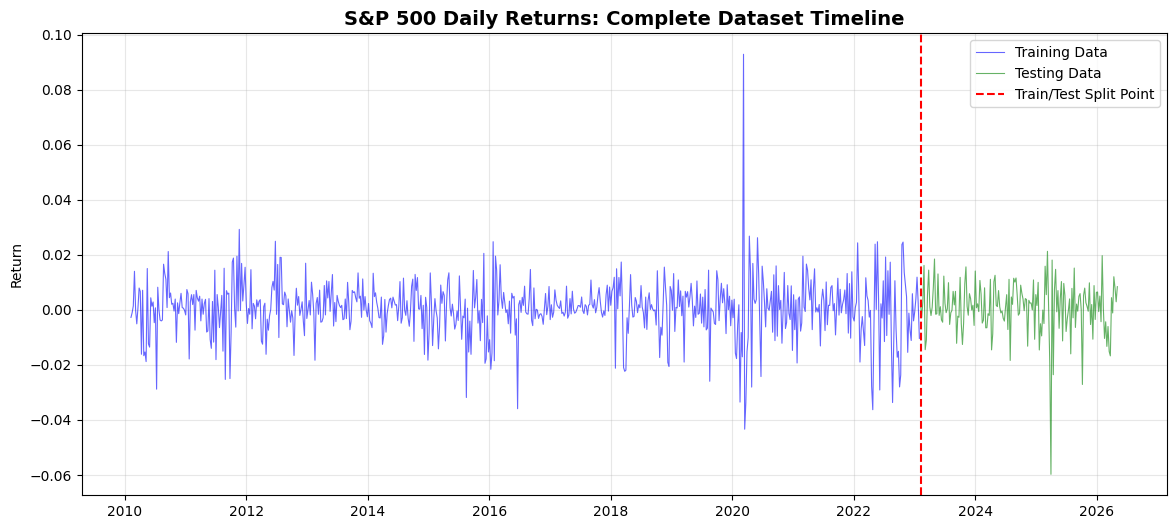

In [5]:
# Plot dataset
plt.figure(figsize=(14, 6))

# Plot training portion
plt.plot(y_train.index, y_train.values, color='blue', alpha=0.6, linewidth=0.8, label='Training Data')
# Plot testing portion
plt.plot(y_test.index, y_test.values, color='green', alpha=0.6, linewidth=0.8, label='Testing Data')

plt.axvline(x=y_test.index.min(), color='red', linestyle='--', label='Train/Test Split Point')
plt.title('S&P 500 Daily Returns: Complete Dataset Timeline', fontsize=14, fontweight='bold')
plt.ylabel('Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Model baselines

### XGBoost

--- Training with seed 42 ---
MSE: 0.000189 | MAE: 0.010489 | Dir. Acc: 46.47%

--- Training with seed 99 ---
MSE: 0.000189 | MAE: 0.010489 | Dir. Acc: 46.47%

--- Training with seed 123 ---
MSE: 0.000189 | MAE: 0.010489 | Dir. Acc: 46.47%

Training Complete!

Generating Plot...


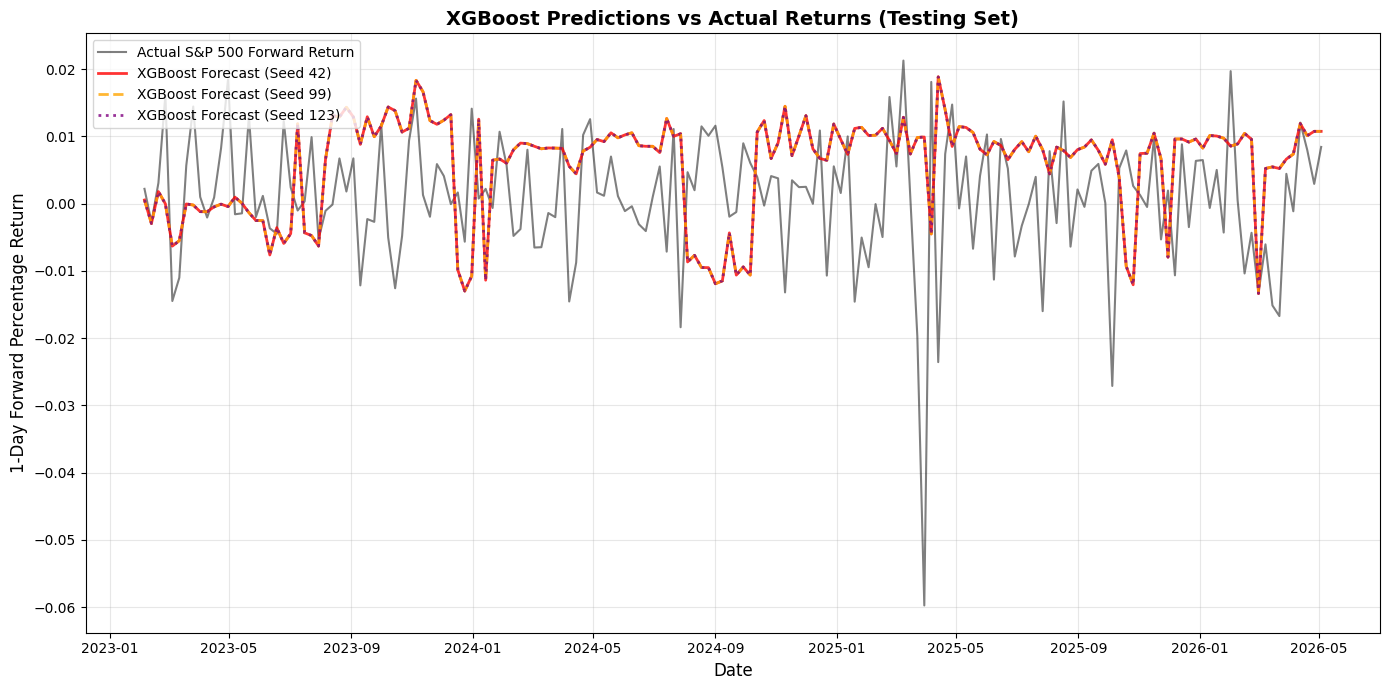

In [6]:
# XGBoost baseline
seeds = [42, 99, 123]
predictions_dict = {}

for seed in seeds:
    print(f"--- Training with seed {seed} ---")
    
    # Initialize XGBoost (Gradient Boosting, Financial Industry Standard)
    xgb_model = XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=3, random_state=seed)
    xgb_model.fit(X_train_scaled, y_train)
    
    # Predict on the scaled testing set
    preds = xgb_model.predict(X_test_scaled)
    
    # Convert numpy array back to Pandas Series with correct dates for easy evaluation
    preds_series = pd.Series(preds, index=y_test.index)
    predictions_dict[seed] = preds_series
    
    # Calculate error metrics
    mse = mean_squared_error(y_test, preds_series)
    mae = mean_absolute_error(y_test, preds_series)
    directional_accuracy = (np.sign(preds_series) == np.sign(y_test)).mean() * 100
    
    print(f"MSE: {mse:.6f} | MAE: {mae:.6f} | Dir. Acc: {directional_accuracy:.2f}%\n")

print("Training Complete!\n")

# ====================================================================
# 7. PLOT THE RESULTS
# ====================================================================
print("Generating Plot...")
plt.figure(figsize=(14, 7))

# Plot actual test values
plt.plot(y_test.index, y_test.values, label='Actual S&P 500 Forward Return', 
         color='black', alpha=0.5, linewidth=1.5)

# Plot predictions for each seed
colors = ['red', 'orange', 'purple']
line_styles = ['-', '--', ':']

for i, seed in enumerate(seeds):
    # Tree-based models like XGBoost can have variance across different random seeds
    # due to stochastic subsampling, so these lines may show slight deviations.
    plt.plot(y_test.index, predictions_dict[seed], label=f'XGBoost Forecast (Seed {seed})', 
             color=colors[i], linestyle=line_styles[i], alpha=0.8, linewidth=2)

plt.title('XGBoost Predictions vs Actual Returns (Testing Set)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('1-Day Forward Percentage Return', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Masked VAE

In [ ]:
class TabularTransformerRegressor(nn.Module):
    def __init__(self, num_features, d_model=32, nhead=4, num_layers=2, dim_feedforward=64, dropout=0.1, mask_prob=0.2):
        super().__init__()
        self.num_features = num_features
        self.mask_prob = mask_prob
        
        # Project each (value, mask) pair into a token of size d_model
        self.token_proj = nn.Linear(2, d_model)
        
        # Feature embeddings (Tabular equivalent of positional encodings) 
        # to distinguish between different macro features (e.g., GDP vs M2)
        self.feature_embeddings = nn.Parameter(torch.randn(1, num_features, d_model))
        
        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Output Head
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, x):
        # Generate random mask during training (1.0 = visible, 0.0 = masked out)
        if self.training and self.mask_prob > 0:
            mask = (torch.rand_like(x) > self.mask_prob).float()
            x_masked = x * mask
        else:
            mask = torch.ones_like(x)
            x_masked = x

        # Prepare tokens: stack value and mask into [batch_size, num_features, 2]
        tokens = torch.stack([x_masked, mask], dim=-1)
        
        # Project tokens to d_model: [batch_size, num_features, d_model]
        x_emb = self.token_proj(tokens)
        
        # Add feature identity embeddings
        x_emb = x_emb + self.feature_embeddings
        
        # Pass through Transformer layers
        encoded = self.transformer(x_emb)
        
        # Mean-pool over the token (sequence) dimension
        pooled = encoded.mean(dim=1)
        
        # Predict the continuous market return
        return self.head(pooled)

def train_and_predict_transformer(X_train, y_train, X_test, seed):
    # Set seeds for absolute reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    num_features = X_train.shape[1]
    model = TabularTransformerRegressor(
        num_features=num_features,
        d_model=32,
        nhead=4,
        num_layers=2,
        dim_feedforward=64,
        dropout=0.1,
        mask_prob=0.2
    )
    
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.MSELoss()
    
    # Prepare DataLoaders
    X_t = torch.FloatTensor(X_train.values)
    y_t = torch.FloatTensor(y_train.values).unsqueeze(1)
    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    
    model.train()
    epochs = 100
    for epoch in range(epochs):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            
            # Forward pass
            preds = model(batch_X)
            
            # Loss and backprop
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
            
    # Evaluation (Inference)
    model.eval()
    with torch.no_grad():
        X_test_t = torch.FloatTensor(X_test.values)
        
        # Predict on test set
        preds = model(X_test_t).squeeze().numpy()
        
    return preds

seeds = [42, 99, 123]
predictions_dict = {}

for seed in seeds:
    print(f"--- Training Tabular Transformer with seed {seed} ---")
    preds = train_and_predict_transformer(X_train_scaled, y_train, X_test_scaled, seed)
    preds_series = pd.Series(preds, index=y_test.index)
    predictions_dict[seed] = preds_series
    
    # Calculate error metrics
    mse = mean_squared_error(y_test, preds_series)
    mae = mean_absolute_error(y_test, preds_series)
    directional_accuracy = (np.sign(preds_series) == np.sign(y_test)).mean() * 100
    
    print(f"MSE: {mse:.6f} | MAE: {mae:.6f} | Dir. Acc: {directional_accuracy:.2f}%")

print("\nTraining Complete!\n")

# Plot results
print("Generating Testing Set Prediction Plot...")
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual S&P 500 Forward Return', color='black', alpha=0.5, linewidth=1.5)

# Plot predictions for each seed
colors = ['blue', 'orange', 'green']
line_styles = ['-', '--', ':']

for i, seed in enumerate(seeds):
    plt.plot(y_test.index, predictions_dict[seed], label=f'Transformer Forecast (Seed {seed})', 
             color=colors[i], linestyle=line_styles[i], alpha=0.8, linewidth=2)

plt.title('Tabular Transformer Predictions vs Actual Returns (Testing Set)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('1-Day Forward Percentage Return', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

--- Training Tabular Transformer with seed 42 ---
